# Simulating Sod-Shock problem

Importing libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt

$E = 0.5 \rho v^2 + P/(\gamma - 1)$ so we will define a function to calulate E at a point

In [3]:
y = 1.4
def E (d, v, P):
    return 0.5* d * v**2 + P/(y - 1)

E(1, 0, 1)

2.5000000000000004

initialising the initial parameters like position, density, pressure, velocity

In [4]:
x =np.linspace(0, 1, 1000)
d = np.zeros(1000)
for i in range(0, 500):
    d[i] = 1
for i in range(500, 1000):
    d[i] = 0.125
v  = np.zeros(1000)
p = np.zeros(1000)
for i in range(0, 500):
    p[i] = 1
for i in range(500, 1000):
    p[i] = 0.1
dx = x[1] - x[0]


prim_to_consv function

In [5]:
def prim_to_cons(d, v, p):
    return np.array([d, d*v, E(d, v, p)])
U = prim_to_cons(d, v, p)


cons_to_prim() defining

In [6]:
def cons_to_prim(U):
    d = U[0, :]
    v = U[1, :] /d
    p = (U[2, :] - 0.5 * d * v*v) * (y-1)
    return d, v , p


computing the dt in each step

In [7]:
def compute_dt(U):
    d, v , p = cons_to_prim(U)
    m = max(np.abs(v) + np.abs(np.sqrt(y * p/d)))
    return 0.5 * dx / m

defining fluxes

In [8]:
def compute_fluxes(U):
    d, v , p = cons_to_prim(U)
    return np.array([d *v,  d * v * v + p , v * (E(d, v, p) + p)])
F = compute_fluxes(U)

Computing flux through interfaces.

In [9]:
cfl = 0.5
def interface_flux(U, F):
    U0, U1 , U2 = U[0,:], U[1,:], U[2,:]
    F0, F1, F2 = F[0,:], F[1,:], F[2,:]
    n = len(U0)
    F_0 , F_1 , F_2 = [], [], []
    a = dx * cfl /( 2* compute_dt(U))
    for i in range (1, n):
        F_0.append(0.5 * (F0[i-1] + F0[i]) - a * (U0[i] - U0[i-1]))
        F_1.append(0.5 * (F1[i-1] + F1[i]) - a * (U1[i] - U1[i-1]))
        F_2.append(0.5 * (F2[i-1] + F2[i]) - a * (U2[i] - U2[i-1]))
    FL0, FL1, FL2 = [0] + F_0, [0] + F_1, [0] + F_2
    FR0, FR1, FR2 =F_0 + [0], F_1 + [0], F_2 + [0]
    FL0, FL1, FL2 = np.array(FL0), np.array(FL1), np.array(FL2)
    FR0, FR1, FR2 = np.array(FR0), np.array(FR1), np.array(FR2)
    FL0 = np.array([F0[0]] + F_0)
    FR0 = np.array(F_0 + [F0[-1]])
    FL1 = np.array([F1[0]] + F_1)
    FR1 = np.array(F_1 + [F1[-1]])
    FL2 = np.array([F2[0]] + F_2)
    FR2 = np.array(F_2 + [F2[-1]])

    F_0 = np.array(FR0 - FL0)
    F_1 = np.array(FR1 - FL1)
    F_2 = np.array(FR2 - FL2)

    return np.array([F_0, F_1, F_2])
F_int = interface_flux(U, F)

updating cells

In [10]:
def update_cells(U, F_interface):
    dt = compute_dt(U)
    return U - (dt / dx) * (F_interface)


SIMULATING

In [21]:
x =np.linspace(0, 1, 1000)
d = np.zeros(1000)
for i in range(0, 500):
    d[i] = 1
for i in range(500, 1000):
    d[i] = 0.125
v  = np.zeros(1000)
p = np.zeros(1000)
for i in range(0, 500):
    p[i] = 1
for i in range(500, 1000):
    p[i] = 0.1
dx = x[1] - x[0]


In [22]:
t = 0
U = prim_to_cons(d, v, p)
while t < 0.3:
    dt = compute_dt(U)
    F = compute_fluxes(U)
    F_int = interface_flux(U, F)
    U = update_cells(U, F_int)
    t += dt



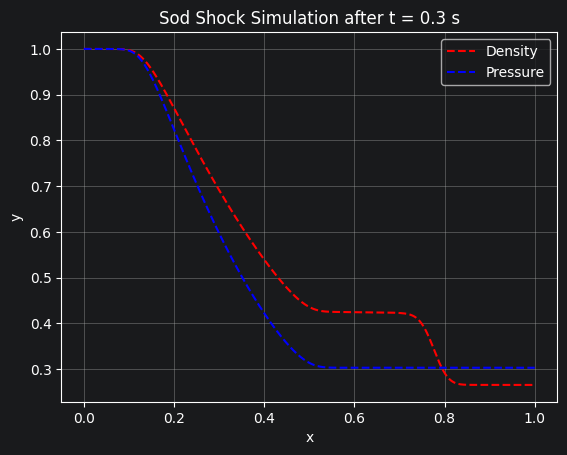

In [23]:
d, v, p = cons_to_prim(U)
plt.plot(x, d, 'r--', label = 'Density')
plt.plot(x, p, 'b--', label = 'Pressure')
plt.legend()
plt.title("Sod Shock Simulation after t = 0.3 s")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

In [14]:
x =np.linspace(0, 1, 1000)
d = np.zeros(1000)
for i in range(0, 500):
    d[i] = 1
for i in range(500, 1000):
    d[i] = 0.125
v  = np.ones(1000)*2
for i in range(500, 1000):
    v[i] = 5
p = np.zeros(1000)
for i in range(0, 500):
    p[i] = 1
for i in range(500, 1000):
    p[i] = 0.1
dx = x[1] - x[0]


In [15]:
t = 0
U = prim_to_cons(d, v, p)
while t < 0.05:
    dt = compute_dt(U)
    F = compute_fluxes(U)
    F_int = interface_flux(U, F)
    U = update_cells(U, F_int)
    t += dt



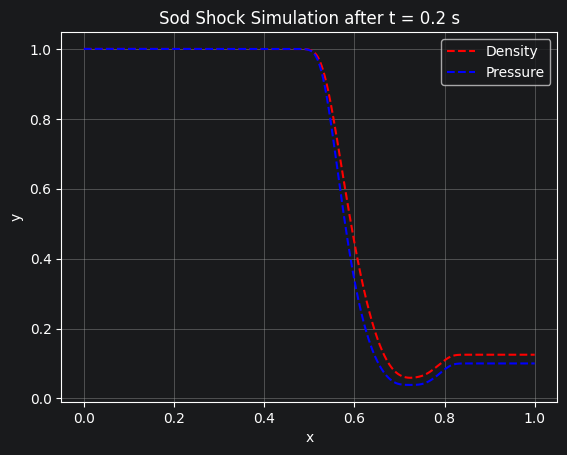

In [16]:
d, v, p = cons_to_prim(U)
plt.plot(x, d, 'r--', label = 'Density')
plt.plot(x, p, 'b--', label = 'Pressure')
plt.legend()
plt.title("Sod Shock Simulation after t = 0.2 s")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()